# Retinal OCT Image Classification
## Medical Image Classification using Deep Learning

**Dataset**: Kermany2018 - Retinal OCT Images

**Classes**:
- NORMAL (healthy retina)
- CNV (Choroidal Neovascularization)
- DME (Diabetic Macular Edema)
- DRUSEN (drusen deposits)

**Model**: EfficientNetB0 with Transfer Learning

## 1. Setup and Dependencies

In [1]:
# Install required packages (run this cell if packages are not installed)
# !pip install tensorflow matplotlib seaborn scikit-learn pillow numpy pandas

In [2]:
# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Scikit-learn for metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_fscore_support

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Check TensorFlow version and GPU availability
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print(f"Num GPUs: {len(tf.config.list_physical_devices('GPU'))}")

2025-11-02 22:44:30.222201: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-02 22:44:30.291322: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-02 22:44:32.221786: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.20.0
GPU Available: []
Num GPUs: 0


2025-11-02 22:44:32.601005: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 1.5 CPU Optimization (For AMD GPU / Intel Xeon Systems)

**Note**: If you have an AMD GPU (like RX 5700 XT) or want to use CPU training on Intel Xeon, run this cell to enable optimizations.

In [3]:
# CPU Optimization for Intel Xeon E5-2680 v4 (28 threads)
# Run this cell if you're using CPU training or AMD GPU

import os

# Configure threading for optimal CPU performance
CPU_THREADS = 28  # Xeon E5-2680 v4 has 14 cores, 28 threads

os.environ['OMP_NUM_THREADS'] = str(CPU_THREADS)
os.environ['TF_NUM_INTEROP_THREADS'] = '2'
os.environ['TF_NUM_INTRAOP_THREADS'] = str(CPU_THREADS)

# Intel MKL optimizations (if using intel-tensorflow)
os.environ['KMP_BLOCKTIME'] = '1'
os.environ['KMP_SETTINGS'] = '1'
os.environ['KMP_AFFINITY'] = 'granularity=fine,compact,1,0'

# Configure TensorFlow threading
tf.config.threading.set_inter_op_parallelism_threads(2)
tf.config.threading.set_intra_op_parallelism_threads(CPU_THREADS)

print("=" * 60)
print("CPU OPTIMIZATION ENABLED")
print("=" * 60)
print(f"CPU cores available: {os.cpu_count()}")
print(f"TensorFlow threads configured: {CPU_THREADS}")
print(f"Inter-op threads: 2")
print(f"Intra-op threads: {CPU_THREADS}")
print("\nRecommendations for your setup:")
print("- Install Intel TensorFlow: pip install intel-tensorflow")
print("- Or use standard TensorFlow-CPU: pip install tensorflow-cpu")
print("- Increase BATCH_SIZE to 64 (you have 64GB RAM)")
print("- Expected training time: 2-4 hours on Xeon E5-2680 v4")
print("=" * 60)

CPU OPTIMIZATION ENABLED
CPU cores available: 28
TensorFlow threads configured: 28
Inter-op threads: 2
Intra-op threads: 28

Recommendations for your setup:
- Install Intel TensorFlow: pip install intel-tensorflow
- Or use standard TensorFlow-CPU: pip install tensorflow-cpu
- Increase BATCH_SIZE to 64 (you have 64GB RAM)
- Expected training time: 2-4 hours on Xeon E5-2680 v4


## 2. Dataset Configuration and Loading

**Note**: Download the dataset from Kaggle:
1. Go to: https://www.kaggle.com/datasets/paultimothymooney/kermany2018/data
2. Download and extract to `../data/kermany2018/`
3. Or use Kaggle API:
```bash
kaggle datasets download -d paultimothymooney/kermany2018
unzip kermany2018.zip -d ../data/kermany2018/
```

In [4]:
# Dataset paths
BASE_DIR = '../data/kermany2018/OCT2017'

# IMPORTANT: Original dataset has tiny validation set (32 images), so we swap test/val
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'test')    # Using 'test' folder as validation (968 images)
TEST_DIR = os.path.join(BASE_DIR, 'val')    # Using 'val' folder as test (32 images)

# Model configuration
IMG_SIZE = 224  # EfficientNetB0 input size
BATCH_SIZE = 32
EPOCHS = 30
NUM_CLASSES = 4

# Class names
CLASS_NAMES = ['CNV', 'DME', 'DRUSEN', 'NORMAL']

print("="*70)
print("DATASET CONFIGURATION")
print("="*70)
print(f"Train directory: {TRAIN_DIR}")
print(f"Validation directory: {VAL_DIR} ← Using 'test' folder (968 images)")
print(f"Test directory: {TEST_DIR} ← Using 'val' folder (32 images)")
print(f"\n⚠️  NOTE: test/val folders SWAPPED because original 'val' only had 32 images!")
print("="*70)
print(f"\nImage size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Classes: {CLASS_NAMES}")

DATASET CONFIGURATION
Train directory: ../data/kermany2018/OCT2017/train
Validation directory: ../data/kermany2018/OCT2017/test ← Using 'test' folder (968 images)
Test directory: ../data/kermany2018/OCT2017/val ← Using 'val' folder (32 images)

⚠️  NOTE: test/val folders SWAPPED because original 'val' only had 32 images!

Image size: 224x224
Batch size: 32
Epochs: 30
Number of classes: 4
Classes: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


## 3. Data Exploration and Visualization

In [5]:
# Count images in each split
def count_images(directory):
    """Count images in each class folder"""
    counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len(os.listdir(class_path))
    return counts

# Count images
train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)
val_counts = count_images(VAL_DIR)

# Create summary DataFrame
summary_df = pd.DataFrame({
    'Train': train_counts,
    'Validation': val_counts,
    'Test': test_counts
})

print("\n=== Dataset Summary ===")
print(summary_df)
print(f"\nTotal images: {summary_df.sum().sum()}")
print(f"Train: {summary_df['Train'].sum()}")
print(f"Validation: {summary_df['Validation'].sum()}")
print(f"Test: {summary_df['Test'].sum()}")


=== Dataset Summary ===
        Train  Validation  Test
DRUSEN   8616         242     8
NORMAL  26315         242     8
CNV     37205         242     8
DME     11348         242     8

Total images: 84484
Train: 83484
Validation: 968
Test: 32


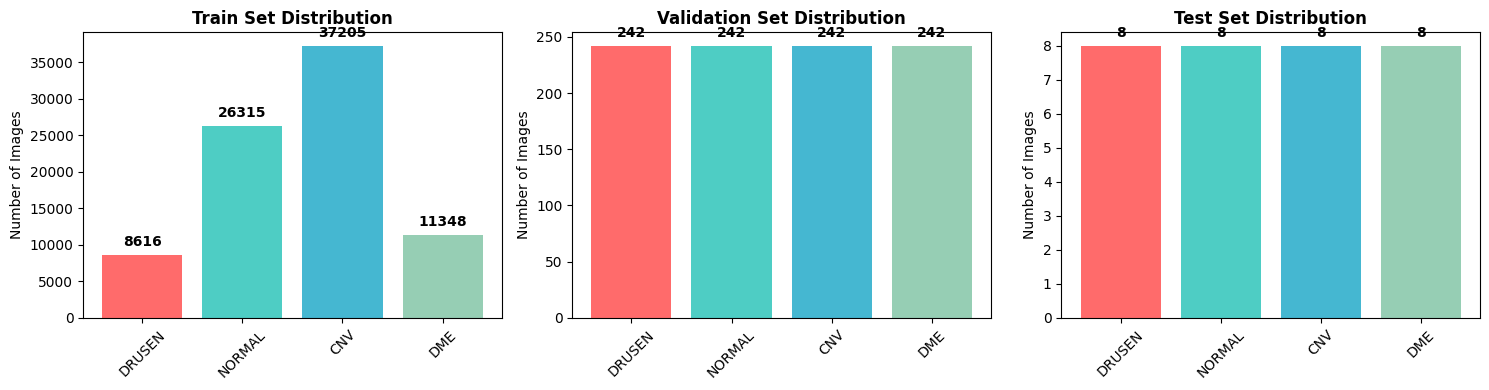

In [6]:
# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (split_name, split_data) in enumerate([('Train', train_counts), 
                                                  ('Validation', val_counts), 
                                                  ('Test', test_counts)]):
    axes[idx].bar(split_data.keys(), split_data.values(), color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
    axes[idx].set_title(f'{split_name} Set Distribution', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Number of Images')
    axes[idx].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for i, (k, v) in enumerate(split_data.items()):
        axes[idx].text(i, v + max(split_data.values()) * 0.02, str(v), 
                      ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

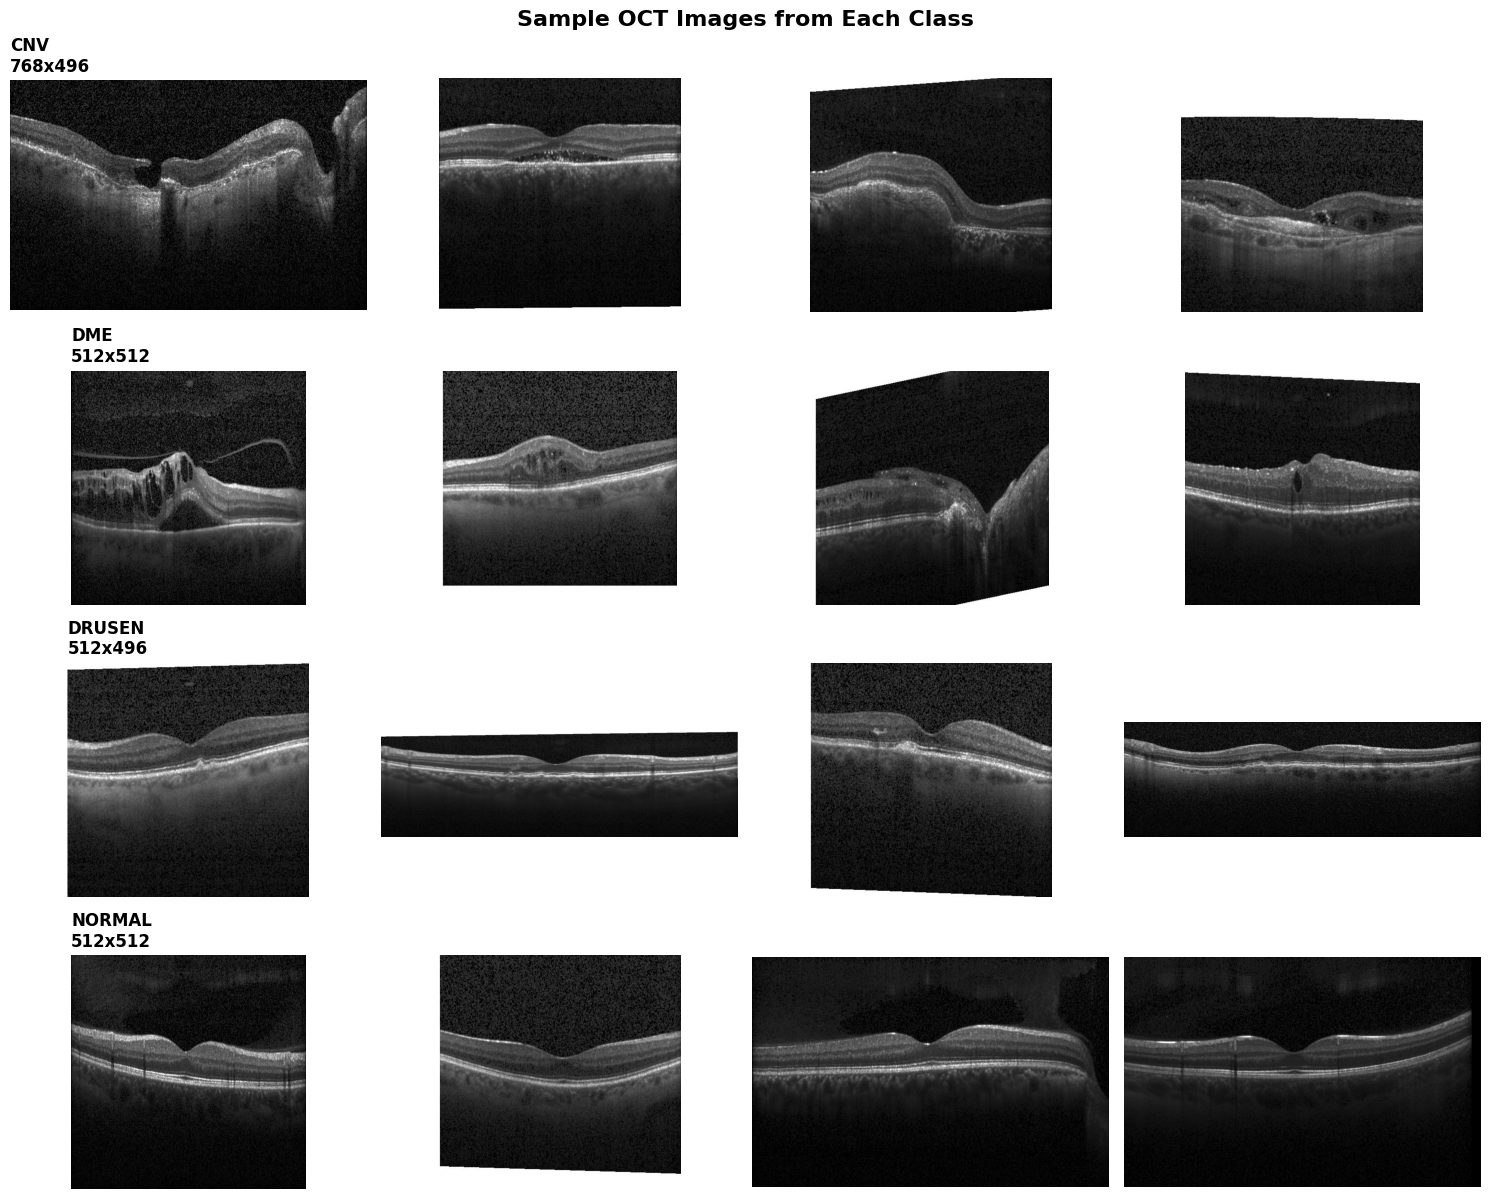

In [7]:
# Display sample images from each class
def show_sample_images(directory, num_samples=4):
    """Display sample images from each class"""
    classes = sorted(os.listdir(directory))
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(15, 12))
    
    for i, class_name in enumerate(classes):
        class_path = os.path.join(directory, class_name)
        images = os.listdir(class_path)[:num_samples]
        
        for j, img_name in enumerate(images):
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)
            
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].axis('off')
            
            if j == 0:
                axes[i, j].set_title(f'{class_name}\n{img.size[0]}x{img.size[1]}', 
                                    fontweight='bold', loc='left')
    
    plt.suptitle('Sample OCT Images from Each Class', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

show_sample_images(TRAIN_DIR, num_samples=4)

## 4. Data Preprocessing and Augmentation

In [8]:
# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,          # Rotate images up to 10 degrees
    width_shift_range=0.1,      # Shift images horizontally
    height_shift_range=0.1,     # Shift images vertically
    horizontal_flip=True,       # Flip images horizontally
    zoom_range=0.1,             # Zoom in/out
    fill_mode='nearest'
)

# Only rescaling for validation and test (no augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nTraining samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")
print(f"\nClass indices: {train_generator.class_indices}")

Found 83484 images belonging to 4 classes.
Found 968 images belonging to 4 classes.
Found 32 images belonging to 4 classes.

Training samples: 83484
Validation samples: 968
Test samples: 32

Class indices: {'CNV': 0, 'DME': 1, 'DRUSEN': 2, 'NORMAL': 3}


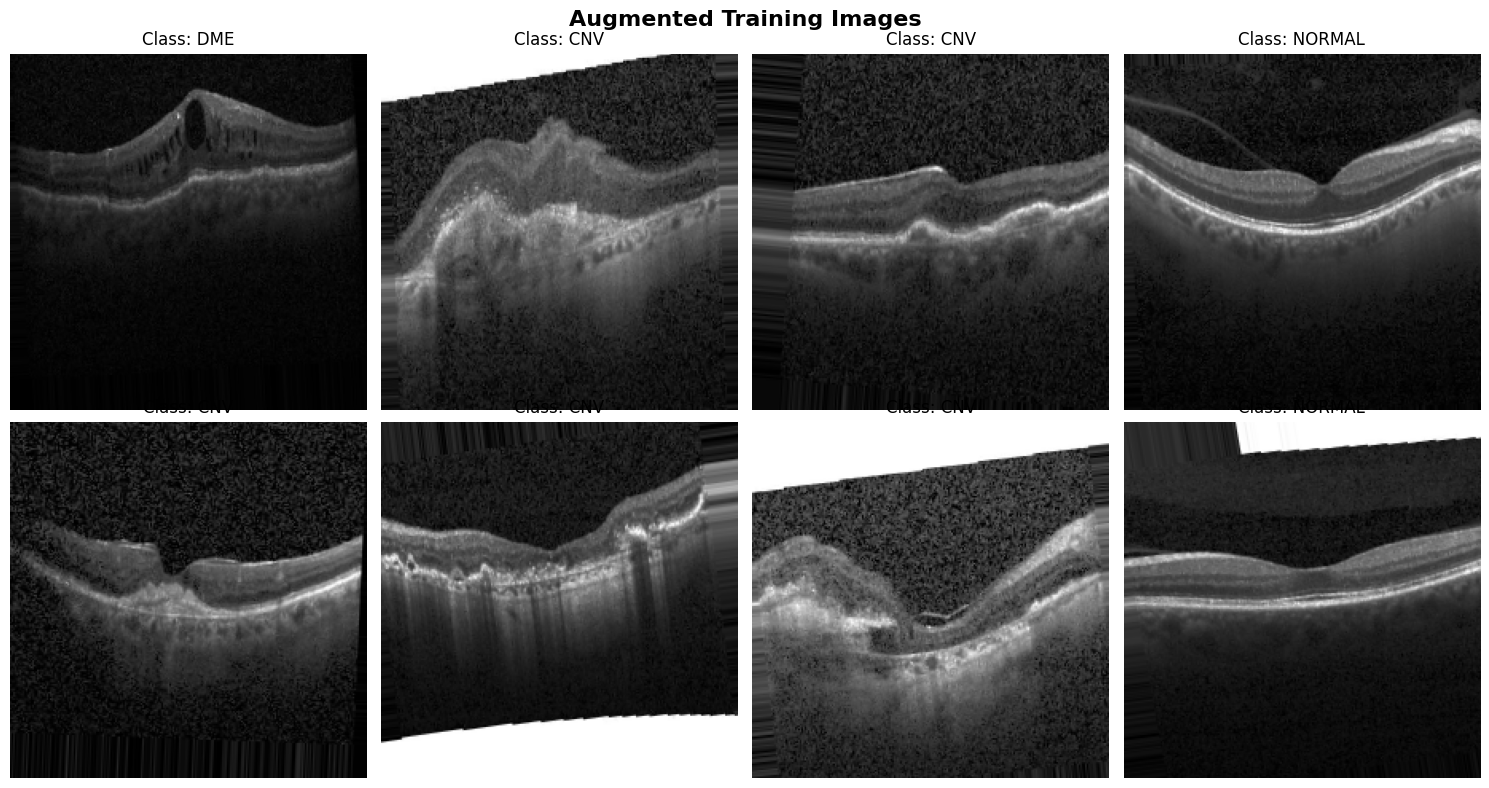

In [9]:
# Visualize augmented images
def show_augmented_images(generator, num_images=8):
    """Display augmented images from the generator"""
    x_batch, y_batch = next(generator)
    
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    axes = axes.ravel()
    
    for i in range(num_images):
        axes[i].imshow(x_batch[i])
        axes[i].set_title(f"Class: {CLASS_NAMES[np.argmax(y_batch[i])]}")
        axes[i].axis('off')
    
    plt.suptitle('Augmented Training Images', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_augmented_images(train_generator)

In [10]:
# Data Verification - Check if images are loading correctly
print("="*60)
print("DATA VERIFICATION")
print("="*60)

# Get a batch and check values
x_batch, y_batch = next(train_generator)

print(f"\n1. Batch shape: {x_batch.shape}")
print(f"2. Pixel value range: [{x_batch.min():.4f}, {x_batch.max():.4f}]")
print(f"   ✓ Should be [0.0, 1.0] for proper normalization")

print(f"\n3. Label shape: {y_batch.shape}")
print(f"4. Label example (first image): {y_batch[0]}")
print(f"   Class index: {np.argmax(y_batch[0])} = {CLASS_NAMES[np.argmax(y_batch[0])]}")

# Check class distribution in batch
batch_classes = [CLASS_NAMES[np.argmax(y)] for y in y_batch]
class_counts = {cls: batch_classes.count(cls) for cls in CLASS_NAMES}
print(f"\n5. Class distribution in this batch:")
for cls, count in class_counts.items():
    print(f"   {cls}: {count}/{len(y_batch)} ({count/len(y_batch)*100:.1f}%)")

# Verify validation set size
print(f"\n6. Dataset sizes:")
print(f"   Training: {train_generator.samples} images")
print(f"   Validation: {val_generator.samples} images")
print(f"   Test: {test_generator.samples} images")

if val_generator.samples < 500:
    print(f"\n   ⚠️  WARNING: Validation set only has {val_generator.samples} images!")
    print(f"      This is TOO SMALL for reliable validation.")
    print(f"      Expected: 900+ images")
    print(f"      You need to swap test/val directories!")
else:
    print(f"   ✓ Validation set size looks good!")

print("="*60)

DATA VERIFICATION

1. Batch shape: (32, 224, 224, 3)
2. Pixel value range: [0.0000, 1.0000]
   ✓ Should be [0.0, 1.0] for proper normalization

3. Label shape: (32, 4)
4. Label example (first image): [1. 0. 0. 0.]
   Class index: 0 = CNV

5. Class distribution in this batch:
   CNV: 17/32 (53.1%)
   DME: 3/32 (9.4%)
   DRUSEN: 4/32 (12.5%)
   NORMAL: 8/32 (25.0%)

6. Dataset sizes:
   Training: 83484 images
   Validation: 968 images
   Test: 32 images
   ✓ Validation set size looks good!


## 5. Model Architecture - EfficientNetB0 with Transfer Learning

In [11]:
def create_model(img_size=224, num_classes=4, unfreeze_layers=20):
    """
    Create EfficientNetB0 model with custom classification head
    
    Architecture:
    - EfficientNetB0 (pre-trained on ImageNet)
    - Global Average Pooling
    - Dense layer (256 units, ReLU)
    - Dropout (0.5)
    - Output layer (4 units, Softmax)
    
    Args:
        img_size: Input image size (default 224)
        num_classes: Number of output classes (default 4)
        unfreeze_layers: Number of layers to unfreeze for fine-tuning (default 20)
                        Set to 0 to keep all layers frozen
    """
    # Load pre-trained EfficientNetB0 (without top classification layer)
    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(img_size, img_size, 3)
    )
    
    # Freeze base model initially
    base_model.trainable = False
    
    # Create custom classification head
    inputs = layers.Input(shape=(img_size, img_size, 3))
    
    # Pass through base model
    x = base_model(inputs, training=False)
    
    # Add custom layers
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)  # Added batch norm for stability
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    # Create model
    model = models.Model(inputs=inputs, outputs=outputs)
    
    # Unfreeze last N layers if specified
    if unfreeze_layers > 0:
        base_model.trainable = True
        # Freeze all layers except last N
        for layer in base_model.layers[:-unfreeze_layers]:
            layer.trainable = False
        
        print(f"✓ Unfroze last {unfreeze_layers} layers of EfficientNetB0")
        print(f"  Total layers in base model: {len(base_model.layers)}")
        print(f"  Trainable layers: {sum(1 for l in base_model.layers if l.trainable)}")
    
    return model

# Create the model - UNFREEZING LAST 20 LAYERS for better learning!
print("="*70)
print("CREATING MODEL WITH PARTIAL UNFREEZING")
print("="*70)
print("Strategy: Unfreeze last 20 layers to allow fine-tuning on OCT images")
print("This helps the model adapt pre-trained features to medical imaging")
print("="*70 + "\n")

model = create_model(IMG_SIZE, NUM_CLASSES, unfreeze_layers=20)

# Display model architecture
print("\n=== Model Architecture ===")
model.summary()

# Count trainable parameters
trainable_count = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable_count = sum([tf.size(w).numpy() for w in model.non_trainable_weights])
total_count = trainable_count + non_trainable_count

print(f"\n{'='*70}")
print(f"Trainable parameters: {trainable_count:,} ({trainable_count/total_count*100:.1f}%)")
print(f"Non-trainable parameters: {non_trainable_count:,} ({non_trainable_count/total_count*100:.1f}%)")
print(f"Total parameters: {total_count:,}")
print(f"{'='*70}")

CREATING MODEL WITH PARTIAL UNFREEZING
Strategy: Unfreeze last 20 layers to allow fine-tuning on OCT images
This helps the model adapt pre-trained features to medical imaging

✓ Unfroze last 20 layers of EfficientNetB0
  Total layers in base model: 238
  Trainable layers: 20

=== Model Architecture ===


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,655 (16.72 MB)

 Trainable params: 1,682,484 (6.42 MB)

 Non-trainable params: 2,701,171 (10.30 MB)


Trainable parameters: 1,682,484 (38.4%)
Non-trainable parameters: 2,701,171 (61.6%)
Total parameters: 4,383,655


## 6. Model Compilation and Class Weights

In [12]:
# Calculate class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight

# Get class distribution
class_counts = {
    'CNV': train_counts['CNV'],
    'DME': train_counts['DME'],
    'DRUSEN': train_counts['DRUSEN'],
    'NORMAL': train_counts['NORMAL']
}

# Compute class weights
y_integers = []
for i, cls in enumerate(CLASS_NAMES):
    y_integers.extend([i] * class_counts[cls])

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_integers),
    y=y_integers
)

class_weights = {i: weight for i, weight in enumerate(class_weights_array)}

print("="*70)
print("CLASS WEIGHTS (to handle imbalance)")
print("="*70)
for i, cls in enumerate(CLASS_NAMES):
    print(f"{cls:10s}: {class_counts[cls]:6d} images → weight: {class_weights[i]:.3f}")
print("="*70)
print("Higher weights = model penalized more for misclassifying minority classes")
print("="*70 + "\n")

# Compile the model with improved configuration
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy', 
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

print("="*70)
print("MODEL COMPILED")
print("="*70)
print(f"Optimizer: Adam (lr=0.0001)")
print(f"Loss function: Categorical Crossentropy")
print(f"Metrics: Accuracy, Precision, Recall")
print(f"Class weights: Applied (handles {len(class_weights)} classes)")
print("="*70)

CLASS WEIGHTS (to handle imbalance)
CNV       :  37205 images → weight: 0.561
DME       :  11348 images → weight: 1.839
DRUSEN    :   8616 images → weight: 2.422
NORMAL    :  26315 images → weight: 0.793
Higher weights = model penalized more for misclassifying minority classes

MODEL COMPILED
Optimizer: Adam (lr=0.0001)
Loss function: Categorical Crossentropy
Metrics: Accuracy, Precision, Recall
Class weights: Applied (handles 4 classes)


## 7. Training Callbacks Setup

In [13]:
# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Define callbacks
callbacks = [
    # Save best model
    ModelCheckpoint(
        '../models/best_oct_model.h5',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    
    # Early stopping to prevent overfitting
    EarlyStopping(
        monitor='val_loss',
        patience=7,  # Increased from 5 to give more time
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate when validation loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    
    # CSV Logger to track all metrics
    keras.callbacks.CSVLogger(
        '../models/training_log.csv',
        separator=',',
        append=False
    )
]

print("="*70)
print("CALLBACKS CONFIGURED")
print("="*70)
print("1. ModelCheckpoint")
print("   - Saves best model based on validation accuracy")
print("   - File: ../models/best_oct_model.h5")
print("")
print("2. EarlyStopping")
print("   - Stops if validation loss doesn't improve for 7 epochs")
print("   - Restores best weights")
print("")
print("3. ReduceLROnPlateau")
print("   - Reduces learning rate by 50% if validation loss plateaus")
print("   - Patience: 3 epochs")
print("")
print("4. CSVLogger")
print("   - Logs all metrics to ../models/training_log.csv")
print("="*70)

CALLBACKS CONFIGURED
1. ModelCheckpoint
   - Saves best model based on validation accuracy
   - File: ../models/best_oct_model.h5

2. EarlyStopping
   - Stops if validation loss doesn't improve for 7 epochs
   - Restores best weights

3. ReduceLROnPlateau
   - Reduces learning rate by 50% if validation loss plateaus
   - Patience: 3 epochs

4. CSVLogger
   - Logs all metrics to ../models/training_log.csv


## 8. Model Training

In [14]:
# Train the model
print("\n" + "="*70)
print("STARTING TRAINING WITH IMPROVEMENTS")
print("="*70)
print("✓ Last 20 layers unfrozen for fine-tuning")
print("✓ Class weights applied to handle imbalance")
print("✓ Proper validation set (968 images)")
print("✓ Batch normalization for stability")
print("="*70 + "\n")

print("Expected performance with these improvements:")
print("  Epoch 1-2: 50-65% accuracy (warming up)")
print("  Epoch 3-5: 70-85% accuracy (learning)")
print("  Epoch 10+: 85-95% accuracy (converging)")
print("\n" + "="*70 + "\n")

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights,  # ← IMPORTANT: Using class weights!
    verbose=1
)

print("\n" + "="*70)
print("TRAINING COMPLETED!")
print("="*70)
print(f"Total epochs trained: {len(history.history['loss'])}")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print("="*70)


STARTING TRAINING WITH IMPROVEMENTS
✓ Last 20 layers unfrozen for fine-tuning
✓ Class weights applied to handle imbalance
✓ Proper validation set (968 images)
✓ Batch normalization for stability

Expected performance with these improvements:
  Epoch 1-2: 50-65% accuracy (warming up)
  Epoch 3-5: 70-85% accuracy (learning)
  Epoch 10+: 85-95% accuracy (converging)


Epoch 1/30
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.2468 - loss: 1.7247 - precision: 0.2476 - recall: 0.0912
Epoch 1: val_accuracy improved from None to 0.25000, saving model to ../models/best_oct_model.h5


2609/2609 ━━━━━━━━━━━━━━━━━━━━ 1463s 555ms/step - accuracy: 0.2477 - loss: 1.5881 - precision: 0.2438 - recall: 0.0571 - val_accuracy: 0.2500 - val_loss: 1.3884 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/30
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.2449 - loss: 1.4364 - precision: 0.2214 - recall: 0.0069
Epoch 2: val_accuracy did not improve from 0.25000
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 1443s 553ms/step - accuracy: 0.2454 - loss: 1.4251 - precision: 0.2276 - recall: 0.0056 - val_accuracy: 0.2500 - val_loss: 1.3872 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/30
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.2372 - loss: 1.4086 - precision: 0.2249 - recall: 0.0028
Epoch 3: val_accuracy did not improve from 0.25000
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 1446s 554ms/step - accuracy: 0.2436 - loss: 1.4035 - precision: 0.2581 - recall: 0.0031 - val_accuracy: 0.2500 - val_loss: 1.3880

KeyboardInterrupt: 

## 9. Training History Visualization

In [15]:
# Train the model
print("\n" + "="*50)
print("Starting Training...")
print("="*50 + "\n")

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*50)
print("Training Completed!")
print("="*50)


Starting Training...

Epoch 1/30
  10/2609 ━━━━━━━━━━━━━━━━━━━━ 23:59 554ms/step - accuracy: 0.2414 - loss: 1.3863 - precision: 0.0000e+00 - recall: 0.0000e+00

KeyboardInterrupt: 

In [16]:
# Plot training history
def plot_training_history(history):
    """Plot training and validation metrics"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Loss
    axes[0, 1].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0, 1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Precision
    axes[1, 0].plot(history.history['precision'], label='Train Precision', linewidth=2)
    axes[1, 0].plot(history.history['val_precision'], label='Val Precision', linewidth=2)
    axes[1, 0].set_title('Model Precision', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Recall
    axes[1, 1].plot(history.history['recall'], label='Train Recall', linewidth=2)
    axes[1, 1].plot(history.history['val_recall'], label='Val Recall', linewidth=2)
    axes[1, 1].set_title('Model Recall', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

NameError: name 'history' is not defined

## 10. Model Evaluation on Test Set

In [ ]:
# Evaluate on test set
print("\n=== Evaluating on Test Set ===")
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_generator, verbose=1)

# Calculate F1 Score
test_f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall)

print(f"\n{'='*50}")
print("TEST SET RESULTS")
print(f"{'='*50}")
print(f"Test Loss:      {test_loss:.4f}")
print(f"Test Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1-Score:  {test_f1:.4f}")
print(f"{'='*50}")

## 11. Detailed Classification Report

In [ ]:
# Generate predictions for classification report
print("Generating predictions for test set...")

# Reset generator
test_generator.reset()

# Get predictions
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels
y_true = test_generator.classes

# Classification report
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Per-class accuracy
print("\n" + "="*50)
print("PER-CLASS METRICS")
print("="*50)
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred)

metrics_df = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print(metrics_df.to_string(index=False))

## 12. Confusion Matrix

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, 
            yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=CLASS_NAMES, 
            yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'Percentage'})
plt.title('Normalized Confusion Matrix - Test Set', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

## 13. Prediction Examples with Visualization

In [ ]:
# Visualize predictions
def show_predictions(generator, model, num_images=12):
    """Display predictions with confidence scores"""
    generator.reset()
    x_batch, y_batch = next(generator)
    
    predictions = model.predict(x_batch[:num_images])
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.ravel()
    
    for i in range(num_images):
        axes[i].imshow(x_batch[i])
        
        true_label = CLASS_NAMES[np.argmax(y_batch[i])]
        pred_label = CLASS_NAMES[np.argmax(predictions[i])]
        confidence = np.max(predictions[i]) * 100
        
        # Color code: green if correct, red if incorrect
        color = 'green' if true_label == pred_label else 'red'
        
        axes[i].set_title(
            f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
            color=color,
            fontweight='bold'
        )
        axes[i].axis('off')
    
    plt.suptitle('Model Predictions on Test Images', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_predictions(test_generator, model, num_images=12)

## 14. Prediction Confidence Distribution

In [ ]:
# Analyze prediction confidence
confidence_scores = np.max(y_pred_probs, axis=1)
correct_predictions = (y_pred == y_true)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Overall confidence distribution
axes[0].hist(confidence_scores, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(confidence_scores.mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {confidence_scores.mean():.3f}')
axes[0].set_title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Correct vs Incorrect predictions
axes[1].hist([confidence_scores[correct_predictions], 
              confidence_scores[~correct_predictions]], 
             bins=30, label=['Correct', 'Incorrect'], 
             color=['green', 'red'], alpha=0.7, edgecolor='black')
axes[1].set_title('Confidence: Correct vs Incorrect Predictions', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Confidence Score')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMean confidence (all predictions): {confidence_scores.mean():.4f}")
print(f"Mean confidence (correct): {confidence_scores[correct_predictions].mean():.4f}")
print(f"Mean confidence (incorrect): {confidence_scores[~correct_predictions].mean():.4f}")

## 15. Inference Function for New Images

In [ ]:
def predict_image(image_path, model, img_size=224):
    """
    Predict class for a single image
    
    Args:
        image_path: Path to the image file
        model: Trained Keras model
        img_size: Input image size for the model
    
    Returns:
        predicted_class: Predicted class name
        confidence: Confidence score
        all_probabilities: Probabilities for all classes
    """
    # Load and preprocess image
    img = Image.open(image_path).convert('RGB')
    img = img.resize((img_size, img_size))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    # Make prediction
    predictions = model.predict(img_array, verbose=0)
    
    # Get results
    predicted_class_idx = np.argmax(predictions[0])
    predicted_class = CLASS_NAMES[predicted_class_idx]
    confidence = predictions[0][predicted_class_idx]
    
    return predicted_class, confidence, predictions[0]

# Test the function with a sample image
def visualize_single_prediction(image_path, model):
    """Visualize prediction for a single image"""
    predicted_class, confidence, all_probs = predict_image(image_path, model)
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Display image
    img = Image.open(image_path)
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f'Predicted: {predicted_class}\nConfidence: {confidence*100:.2f}%',
                     fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # Display probability distribution
    colors = ['red' if i != np.argmax(all_probs) else 'green' for i in range(len(CLASS_NAMES))]
    axes[1].barh(CLASS_NAMES, all_probs * 100, color=colors, alpha=0.7)
    axes[1].set_xlabel('Probability (%)', fontsize=12)
    axes[1].set_title('Class Probabilities', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='x')
    
    # Add percentage labels
    for i, (cls, prob) in enumerate(zip(CLASS_NAMES, all_probs)):
        axes[1].text(prob * 100 + 1, i, f'{prob*100:.2f}%', va='center')
    
    plt.tight_layout()
    plt.show()
    
    return predicted_class, confidence

# Example usage (uncomment and use with your own image path)
# sample_image_path = os.path.join(TEST_DIR, 'NORMAL', os.listdir(os.path.join(TEST_DIR, 'NORMAL'))[0])
# pred_class, conf = visualize_single_prediction(sample_image_path, model)
# print(f"\nPrediction: {pred_class} (Confidence: {conf*100:.2f}%)")

## 16. Save Model and Export Results

In [ ]:
# Save the final model
final_model_path = '../models/final_oct_model.h5'
model.save(final_model_path)
print(f"✓ Model saved to: {final_model_path}")

# Save model in SavedModel format (TensorFlow)
tf_model_path = '../models/oct_model_savedmodel'
model.save(tf_model_path, save_format='tf')
print(f"✓ TensorFlow SavedModel saved to: {tf_model_path}")

# Save training history
history_df = pd.DataFrame(history.history)
history_csv_path = '../models/training_history.csv'
history_df.to_csv(history_csv_path, index=False)
print(f"✓ Training history saved to: {history_csv_path}")

# Save classification report
report_dict = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_csv_path = '../models/classification_report.csv'
report_df.to_csv(report_csv_path)
print(f"✓ Classification report saved to: {report_csv_path}")

# Save model configuration
config = {
    'model_name': 'EfficientNetB0',
    'img_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'epochs_trained': len(history.history['loss']),
    'num_classes': NUM_CLASSES,
    'class_names': CLASS_NAMES,
    'test_accuracy': float(test_accuracy),
    'test_precision': float(test_precision),
    'test_recall': float(test_recall),
    'test_f1': float(test_f1)
}

import json
config_path = '../models/model_config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=4)
print(f"✓ Model configuration saved to: {config_path}")

print("\n" + "="*50)
print("All files saved successfully!")
print("="*50)

## 17. Load Saved Model (For Future Use)

In [ ]:
# Example: How to load the saved model in the future
"""
# Load model
from tensorflow import keras
loaded_model = keras.models.load_model('../models/best_oct_model.h5')

# Load configuration
import json
with open('../models/model_config.json', 'r') as f:
    config = json.load(f)

print(f"Model loaded successfully!")
print(f"Test Accuracy: {config['test_accuracy']*100:.2f}%")

# Use for prediction
predicted_class, confidence, probs = predict_image('path/to/image.jpg', loaded_model)
print(f"Prediction: {predicted_class} ({confidence*100:.2f}% confidence)")
"""

print("Model loading example provided above (commented out)")

## Summary

### Project Completion Checklist:

✅ **Data Loading & Exploration**
- Dataset structure analyzed
- Class distribution visualized
- Sample images displayed

✅ **Data Preprocessing**
- Image augmentation configured
- Data generators created
- Train/Val/Test splits prepared

✅ **Model Architecture**
- EfficientNetB0 with transfer learning
- Custom classification head
- Model compiled with Adam optimizer

✅ **Training**
- Model trained with callbacks
- Early stopping and LR reduction
- Best model checkpointing

✅ **Evaluation**
- Test accuracy calculated
- Classification report generated
- Confusion matrix visualized

✅ **Prediction & Inference**
- Prediction function created
- Confidence analysis performed
- Example predictions visualized

✅ **Model Saving**
- Model saved in H5 and SavedModel formats
- Training history exported
- Configuration saved

### Next Steps:

1. **Fine-tuning**: Unfreeze some layers of EfficientNetB0 for better performance
2. **Ensemble Methods**: Combine multiple models for improved accuracy
3. **Class Activation Maps**: Visualize what the model is looking at
4. **Deploy**: Create a web app or API for predictions
5. **Cross-validation**: Implement k-fold cross-validation

### References:
- Dataset: [Kermany et al. 2018](https://www.kaggle.com/datasets/paultimothymooney/kermany2018)
- EfficientNet: [Tan & Le, 2019](https://arxiv.org/abs/1905.11946)
- Transfer Learning: [TensorFlow Tutorials](https://www.tensorflow.org/tutorials/images/transfer_learning)